# **Hate Speech Detection**

tweets from x servered as the dataset

## **Importing Libraries**

In [1]:
import pandas as pd
import spacy
import numpy as np
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
#from keras.regularizers import l2
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv('/content/labeled_data.csv')

In [15]:
df.columns

Index(['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither',
       'class', 'tweet'],
      dtype='object')

In [16]:
df.shape

(24783, 7)

- 0 - hate speech
- 1 - offensive language
- 2 - neither

## **Data Cleaning**

### **Deleting Unwanted column**

In [17]:
df.drop(columns = ['Unnamed: 0',	'count',	'hate_speech',	'offensive_language',	'neither'], inplace = True)

In [18]:
df

,class,tweet
0,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
...,...,...
24778,1,you's a muthaf***in lie &#8220;@LifeAsKing: @2...
24779,2,"you've gone and broke the wrong heart baby, an..."
24780,1,young buck wanna eat!!.. dat nigguh like I ain...
24781,1,youu got wild bitches tellin you lies


### **Null Values?**

In [20]:
df.isna().sum()

,0
class,0
tweet,0


### **Replacing the unwanted charecters**

In [21]:
df['processed_tweet'] = df['tweet'].str.replace(r'[^a-zA-Z]', ' ', regex = True)

#### Now removing the white spaces

In [23]:
df['processed_tweet_2'] = df['processed_tweet'].str.replace(r'[\s]+', ' ', regex = True)

In [24]:
df.drop(columns = ['tweet', 'processed_tweet'], inplace = True)

In [25]:
df.head()

,class,processed_tweet_2
0,2,RT mayasolovely As a woman you shouldn t comp...
1,1,RT mleew boy dats cold tyga dwn bad for cuffi...
2,1,RT UrKindOfBrand Dawg RT sbaby life You ever ...
3,1,RT C G Anderson viva based she look like a tr...
4,1,RT ShenikaRoberts The shit you hear about me ...


### Replace the target values

In [ ]:
# # 5. REPLACING THE TARGET VALUES
# df['class'].replace({0 : 'hate', 1 : 'offensive', 2 : 'neither'}, inplace = True)

In [26]:
df.head()

,class,processed_tweet_2
0,2,RT mayasolovely As a woman you shouldn t comp...
1,1,RT mleew boy dats cold tyga dwn bad for cuffi...
2,1,RT UrKindOfBrand Dawg RT sbaby life You ever ...
3,1,RT C G Anderson viva based she look like a tr...
4,1,RT ShenikaRoberts The shit you hear about me ...


## **Taking care of the NLP part**

Using spacy instead of nltk

In [27]:
# load out spacy modeule
nlp = spacy.load('en_core_web_sm')

### **Lemmatization of the dataset**

Lemmatization is a natural language processing (NLP) technique that reduces inflected words to their dictionary base form, called a lemma (e.g., "studies" -> "study", "better" -> "good")

In [28]:
# 6. LEMMATIZATION
def lemmatization(text):
  doc = nlp(text)
  lemmaList = [word.lemma_ for word in doc]
  return ' '.join(lemmaList)

df['lemma_tweet'] = df['processed_tweet_2'].apply(lemmatization)

In [29]:
df.head()

,class,processed_tweet_2,lemma_tweet
0,2,RT mayasolovely As a woman you shouldn t comp...,RT mayasolovely as a woman you shouldn t com...
1,1,RT mleew boy dats cold tyga dwn bad for cuffi...,RT mleew boy dat cold tyga dwn bad for cuffi...
2,1,RT UrKindOfBrand Dawg RT sbaby life You ever ...,RT UrKindOfBrand Dawg RT sbaby life you ever...
3,1,RT C G Anderson viva based she look like a tr...,RT C G Anderson viva base she look like a tr...
4,1,RT ShenikaRoberts The shit you hear about me ...,RT ShenikaRoberts the shit you hear about I ...


### **Removing the Stopword from the data**

In [30]:
def remove_stopwords(text):
  doc = nlp(text)
  no_stopwords_list = [word.text for word in doc if not word.is_stop]
  return ' '.join(no_stopwords_list)

df['final_tweet'] = df['lemma_tweet'].apply(remove_stopwords)

Stopword removal is a common NLP preprocessing step that eliminates frequently occurring words

In [31]:
df.head()

,class,processed_tweet_2,lemma_tweet,final_tweet
0,2,RT mayasolovely As a woman you shouldn t comp...,RT mayasolovely as a woman you shouldn t com...,RT mayasolovely woman shouldn t complain cl...
1,1,RT mleew boy dats cold tyga dwn bad for cuffi...,RT mleew boy dat cold tyga dwn bad for cuffi...,RT mleew boy dat cold tyga dwn bad cuffin d...
2,1,RT UrKindOfBrand Dawg RT sbaby life You ever ...,RT UrKindOfBrand Dawg RT sbaby life you ever...,RT UrKindOfBrand Dawg RT sbaby life fuck bi...
3,1,RT C G Anderson viva based she look like a tr...,RT C G Anderson viva base she look like a tr...,RT C G Anderson viva base look like tranny
4,1,RT ShenikaRoberts The shit you hear about me ...,RT ShenikaRoberts the shit you hear about I ...,RT ShenikaRoberts shit hear true faker bitc...


In [32]:
df.columns

Index(['class', 'processed_tweet_2', 'lemma_tweet', 'final_tweet'], dtype='object')

In [33]:
df.drop(columns = ['processed_tweet_2', 'lemma_tweet'], inplace = True)

No more NLP pre processing is needed

## **Standardization and one hot encoding**

### **One hot representation**

changes words -> number to make the model understand

In [34]:
vocab_size = 10000
one_hot_representation = [one_hot(words, vocab_size) for words in df['final_tweet']]

### **Padding and Embeddings**

padding is adding 0s until it hit the sentence length in one hot encoded sentences

In [35]:
sentence_length = 20
embedded_tweet = pad_sequences(one_hot_representation, padding='pre', maxlen = sentence_length)

doing pre(0s before the number seq) padding here -> post(0s abter the number seq) padding for some reason dropping the accuracy

In [ ]:
embedded_tweet[0]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0, 2587, 6321,
       8043,  599, 6796, 8780, 5681, 3679, 6096, 3790, 4738], dtype=int32)

## **Dividing data into x and y**

In [36]:
X = np.array(embedded_tweet)
y = np.array(df['class'])

In [38]:
df['class'].value_counts()

,count
class,
1,19190
2,4163
0,1430


Since the data is not balanced using SMOTE to balace the data

### **Generate Synthetic dataset to balnce the dataset**

Using SMOTE for this task
genreating synthetic sample for class 0 (thats why using minority)
if used auto then all the classes have same number of data which can drop the accuracy

In [39]:
smote = SMOTE(sampling_strategy='minority')
X, y = smote.fit_resample(X, y)

### **Now splitting the datasert into training and testing set**

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 43)

## **Creating the model**

building an RNN for this

In [44]:
dimension = 50 #features and factors on which we prioratize eevery word

model = keras.Sequential([
    #embedding layer
    keras.layers.Embedding(vocab_size, dimension, input_length = sentence_length),
    # LSTM layer
    keras.layers.LSTM(100,return_sequences=True),
    keras.layers.LSTM(50, return_sequences=True),
    keras.layers.LSTM(50),
    #output layer
    keras.layers.Dense(3, activation = 'softmax')
])

#best optimizer is adam
model.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

In [ ]:
model.summary()

In [46]:
model.fit(X_train, y_train, epochs = 10, batch_size=32)

Epoch 1/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8678 - loss: 0.3462
Epoch 2/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9429 - loss: 0.1739
Epoch 3/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9588 - loss: 0.1285
Epoch 4/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9685 - loss: 0.1003
Epoch 5/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9755 - loss: 0.0804
Epoch 6/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9805 - loss: 0.0615
Epoch 7/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.9856 - loss: 0.0441
Epoch 8/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9899 - loss: 0.0320
Epoch 9/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.9925 - loss: 0.0237
Epoch 10/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.9952 - loss: 0.0159


## **Evaluatiing accuracy**

In [53]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Model Accuracy : {accuracy}')

266/266 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9014 - loss: 0.5577
Model Accuracy : 0.9013985395431519


the model is 90% accurate

### **Now trying on test cases**

In [54]:
pred = np.argmax(model.predict(X_test), axis = -1)

266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [55]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.93      0.92      0.92      3866
           1       0.91      0.92      0.91      3808
           2       0.75      0.72      0.74       835

    accuracy                           0.90      8509
   macro avg       0.86      0.86      0.86      8509
weighted avg       0.90      0.90      0.90      8509



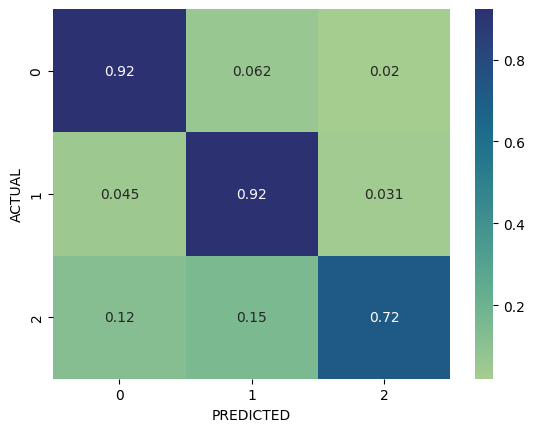

In [56]:
cf = confusion_matrix(y_test, pred, normalize = 'true')
sns.heatmap(cf, annot = True, cmap = 'crest')
plt.xlabel('PREDICTED'),
plt.ylabel('ACTUAL');

the heatmap is normalized since i have >50k data

## **Saving the Model to Google Drive as .pkl**

In [57]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [58]:
import pickle
model_save_path = '/content/drive/MyDrive/hate_speech_detection_model.pkl'

with open(model_save_path, 'wb') as file:
    pickle.dump(model, file)

print(f"Model saved successfully to '{model_save_path}'")

Model saved successfully to '/content/drive/MyDrive/hate_speech_detection_model.pkl'


This will save your model in the `.pkl` format to your Google Drive. You can load it later using `with open('/content/drive/MyDrive/hate_speech_detection_model.pkl', 'rb') as file: loaded_model = pickle.load(file)`.

## **Saving the Model**

In [ ]:
model.save('hate_speech_detection_model.keras')
print("Model saved successfully to 'hate_speech_detection_model.keras'")

This will save your model in the Keras format, which can be loaded later using `tf.keras.models.load_model('hate_speech_detection_model.keras')`.